In [ ]:
import pandas as pd
df = pd.read_csv('data/raw/essay/train.csv')
print(df.shape)
print(df['score'].value_counts().sort_index())
print(df['full_text'].str.split().str.len().describe())

(17307, 3)
score
1    1252
2    4723
3    6280
4    3926
5     970
6     156
Name: count, dtype: int64
count    17307.000000
mean       368.348241
std        150.394776
min        150.000000
25%        253.000000
50%        345.000000
75%        452.000000
max       1656.000000
Name: full_text, dtype: float64


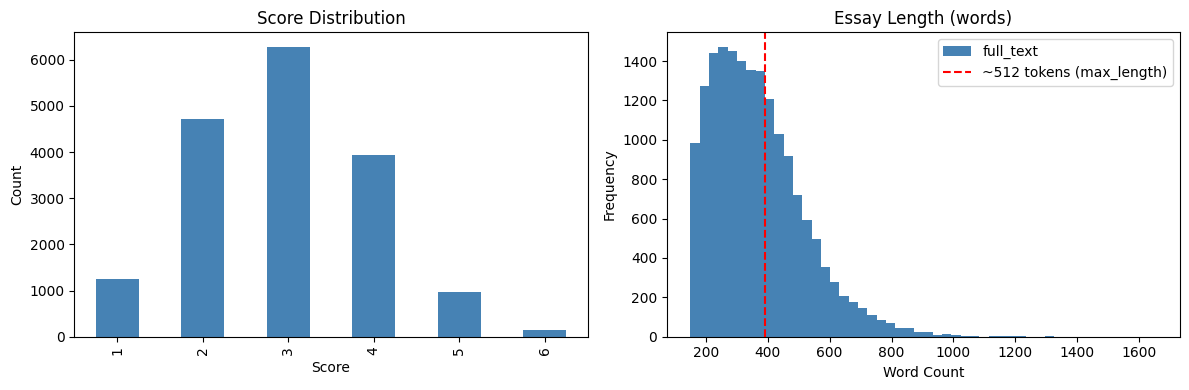

EDA plot saved.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/essay/train.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Score distribution
df['score'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

# Essay length distribution
df['full_text'].str.split().str.len().plot(kind='hist', bins=50, ax=axes[1], color='steelblue')
axes[1].axvline(x=390, color='red', linestyle='--', label='~512 tokens (max_length)')
axes[1].set_title('Essay Length (words)')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.tight_layout()
plt.show()
print("EDA plot saved.")

In [5]:
"""Stratified K-fold training loop for essay scorer."""

import os
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
from sklearn.model_selection import StratifiedKFold

from src.data.essay_dataset import EssayDataset
from src.models.essay_model import EssayScorer
from src.evaluation.essay_metrics import quadratic_weighted_kappa, mean_squared_error
from src.utils.config import load_config


def train_one_epoch(model, loader, optimizer, scheduler, device):
    """One training epoch. Returns mean train loss."""
    model.train()
    total_loss = 0.0
    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        token_type_ids = batch.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(device)

        loss, _ = model(input_ids, attention_mask, token_type_ids, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, device):
    """Validation pass. Returns (qwk, mse, raw_preds, true_labels)."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            true_labels = batch["labels"].numpy()
            token_type_ids = batch.get("token_type_ids")
            if token_type_ids is not None:
                token_type_ids = token_type_ids.to(device)

            _, logits = model(input_ids, attention_mask, token_type_ids)
            all_preds.extend(logits.cpu().numpy())
            all_labels.extend(true_labels)

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    qwk = quadratic_weighted_kappa(all_labels, all_preds)
    mse_val = mean_squared_error(all_labels, all_preds)
    return qwk, mse_val, all_preds, all_labels


def run_cv(config_path: str = "configs/config.yaml"):
    """Run 5-fold stratified CV and save OOF predictions + per-fold models."""
    cfg = load_config(config_path)["stage2"]

    torch.manual_seed(cfg["seed"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    df = pd.read_csv(cfg["train_path"])
    tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
    os.makedirs(cfg["output_dir"], exist_ok=True)

    skf = StratifiedKFold(n_splits=cfg["n_folds"], shuffle=True, random_state=cfg["seed"])
    oof_preds = np.zeros(len(df))
    fold_qwks = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(df, df["score"])):
        print(f"\n{'='*50}\nFOLD {fold + 1} / {cfg['n_folds']}\n{'='*50}")

        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        train_ds = EssayDataset(train_df, tokenizer, cfg["max_length"])
        val_ds = EssayDataset(val_df, tokenizer, cfg["max_length"])

        train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"],
                                  shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"] * 2,
                                shuffle=False, num_workers=2, pin_memory=True)

        model = EssayScorer(cfg["model_name"], cfg["dropout"])
        model.to(device)
        model.backbone.gradient_checkpointing_enable()  # saves ~30% VRAM

        optimizer = AdamW(
            model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"]
        )
        total_steps = len(train_loader) * cfg["epochs"]
        warmup_steps = int(total_steps * cfg["warmup_ratio"])
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

        best_qwk, best_preds = -1.0, None
        fold_save_dir = os.path.join(cfg["output_dir"], f"fold_{fold + 1}")

        for epoch in range(cfg["epochs"]):
            train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device)
            val_qwk, val_mse, val_preds, _ = evaluate(model, val_loader, device)
            print(
                f"  Epoch {epoch + 1}/{cfg['epochs']} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val QWK: {val_qwk:.4f} | Val MSE: {val_mse:.4f}"
            )
            if val_qwk > best_qwk:
                best_qwk = val_qwk
                best_preds = val_preds.copy()
                model.save_scorer(fold_save_dir, tokenizer)
                print(f"  → Best so far. Saved to {fold_save_dir}")

        oof_preds[val_idx] = best_preds
        fold_qwks.append(best_qwk)
        print(f"Fold {fold + 1} best QWK: {best_qwk:.4f}")

        # Free VRAM between folds
        del model, optimizer, scheduler, train_loader, val_loader
        torch.cuda.empty_cache()

    # OOF metrics
    oof_qwk = quadratic_weighted_kappa(df["score"].values, oof_preds)
    oof_mse = mean_squared_error(df["score"].values, oof_preds)
    print(f"\nOOF QWK: {oof_qwk:.4f} | OOF MSE: {oof_mse:.4f}")
    print(f"Per-fold QWKs: {[round(q, 4) for q in fold_qwks]}")

    # Save OOF predictions
    oof_path = os.path.join(cfg["output_dir"], "oof_predictions.csv")
    pd.DataFrame({
        "essay_id": df["essay_id"],
        "true_score": df["score"],
        "oof_pred_raw": oof_preds,
        "oof_pred_rounded": np.clip(np.round(oof_preds), 1, 6).astype(int),
    }).to_csv(oof_path, index=False)
    print(f"OOF predictions saved to {oof_path}")

    return oof_qwk, fold_qwks

c:\Users\yashg\edtech-nlp-pipeline\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import sys
sys.path.insert(0, '..')
from src.training.essay_trainer import run_cv

oof_qwk, fold_qwks = run_cv('../configs/config.yaml')

ImportError: cannot import name 'run_cv' from 'src.training.essay_trainer' (c:\Users\yashg\edtech-nlp-pipeline\notebooks\..\src\training\essay_trainer.py)